In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


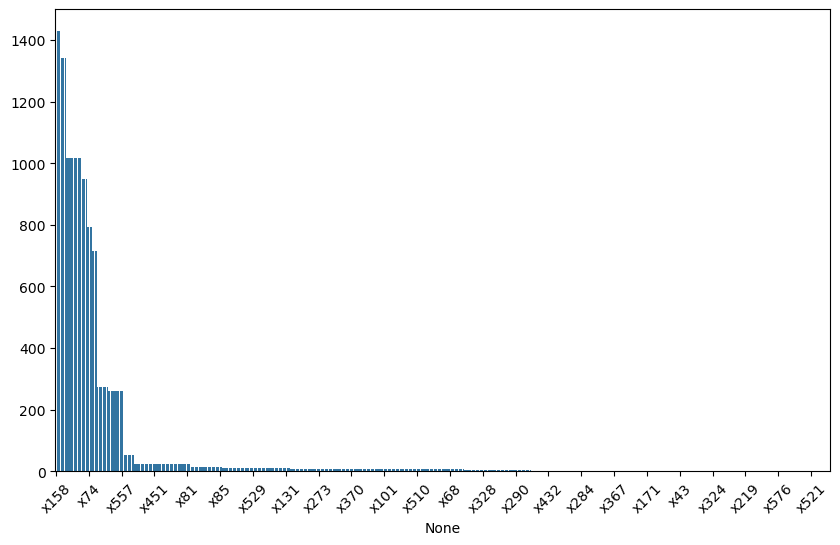

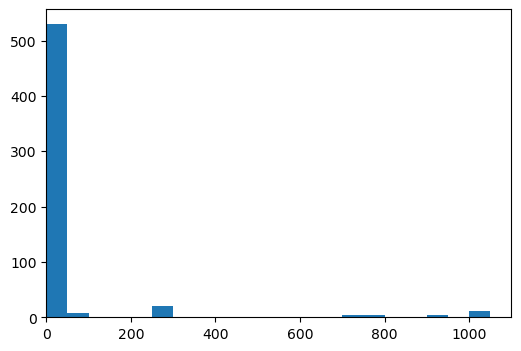

In [2]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=na_counts.index, y=na_counts.values)
plt.xticks(range(0, len(na_counts), 25), na_counts.index[::25], rotation=45)
plt.show()

na_s = X.isna().sum()
plt.figure(figsize=(6, 4))
plt.hist(na_s.values, bins=np.arange(0, 1150, 50))
plt.xlim(0, 1100)
plt.show()

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


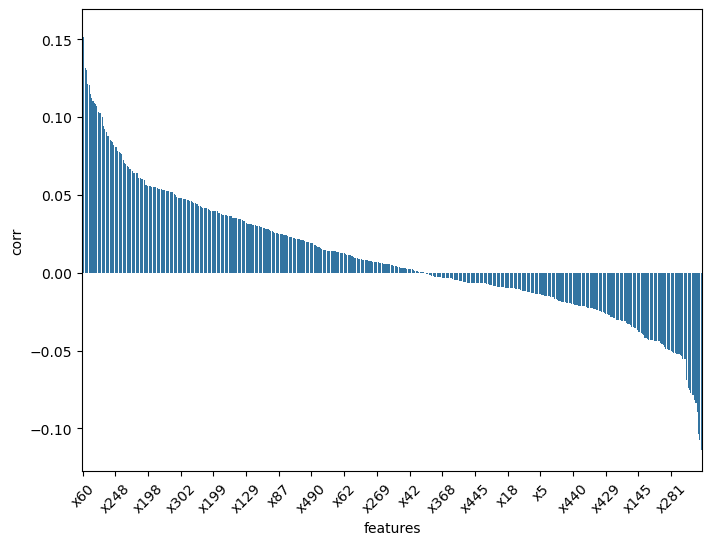

In [3]:
xy_corr = X.corrwith(y).dropna().sort_values(ascending=False)
xy_corr_df = xy_corr.reset_index()
xy_corr_df.columns = ['features', 'corr']
plt.figure(figsize=(8, 6))
sns.barplot(data=xy_corr_df, x='features', y='corr')
plt.xticks(range(0, len(xy_corr), 25), xy_corr.index[::25], rotation=45)
plt.show()

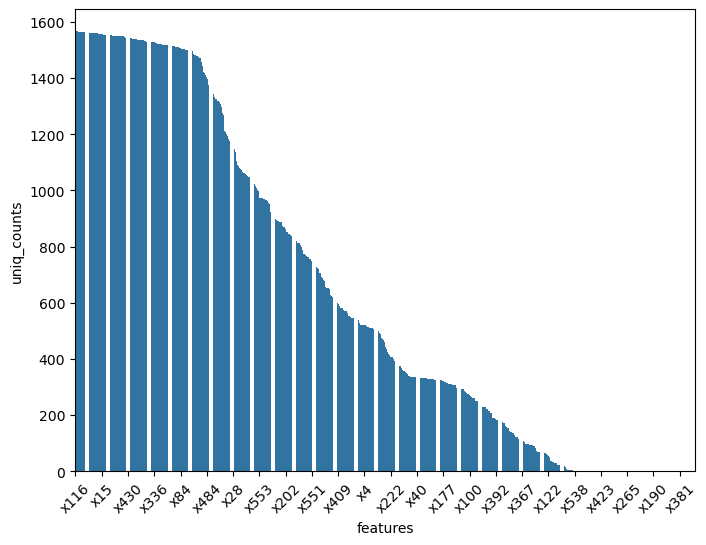

In [4]:
uniq_counts_incl_nas = X.apply(lambda x: x.nunique(dropna=False)).sort_values(ascending=False)
uniq_counts_incl_nas_df = uniq_counts_incl_nas.reset_index()
uniq_counts_incl_nas_df.columns = ['features', 'uniq_counts']
plt.figure(figsize=(8, 6))
sns.barplot(data=uniq_counts_incl_nas_df, x='features', y='uniq_counts')
plt.xticks(range(0, len(uniq_counts_incl_nas), 25), uniq_counts_incl_nas.index[::25], rotation=45)
plt.show()

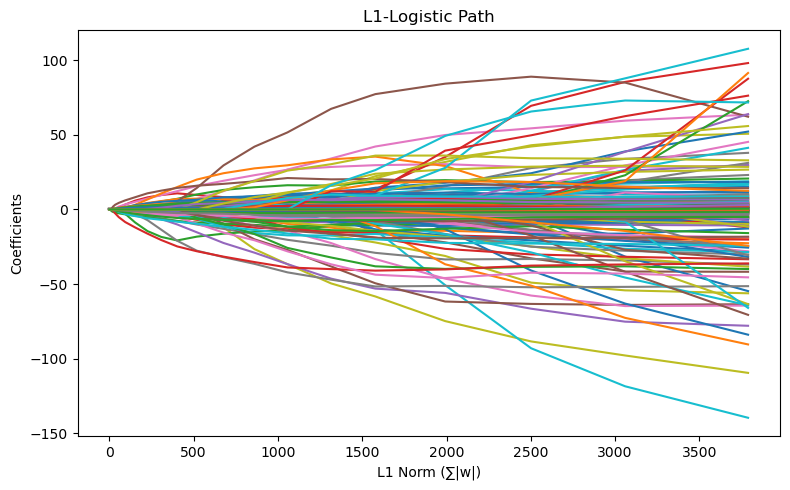

In [10]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)
# 1) 標準化
scaler = StandardScaler()
Xz = scaler.fit_transform(X_imputed.values)
y_arr = y.values.astype(int)
feat_names = np.array(X_imputed.columns)

Cs = np.logspace(3, -4, 40)  # C 大→懲罰弱；從弱到強掃
clf = LogisticRegressionCV(Cs=Cs, penalty='l1', solver='liblinear', cv=5, max_iter=1000, n_jobs=-1, refit=True).fit(X_imputed, y)

# 係數路徑：對 folds 取平均
paths = clf.coefs_paths_[1]          # (n_folds, len(Cs), n_features)
coef_path = paths.mean(axis=0)       # (len(Cs), n_features)

# 1) 橫軸 = L1 範數 ∑|w|
l1_norm = np.abs(coef_path).sum(axis=1)
plt.figure(figsize=(8,5))
plt.plot(l1_norm, coef_path)
plt.xlabel('L1 Norm (∑|w|)')
plt.ylabel('Coefficients')
plt.title('L1-Logistic Path')
plt.tight_layout(); plt.show()

In [12]:
best_C = float(np.ravel(clf.C_)[0])   # CV 選到的 C
best_lambda = 1.0 / best_C

print("best C =", best_C)
print("best λ =", best_lambda)

best C = 0.00022854638641349884
best λ = 4375.479375074189


In [13]:
coef = pd.Series(clf.coef_.ravel(), index=X_imputed.columns)

# 被選到的特徵＝係數 ≠ 0
selected = coef[coef != 0].sort_values(key=np.abs, ascending=False)

n_selected = int(selected.shape[0])
top10 = selected.index[:10].tolist()

print("最佳 C =", float(np.ravel(clf.C_)[0]), "→ 最佳 λ =", 1/float(np.ravel(clf.C_)[0]))
print("入選特徵數 =", n_selected)
print("前10名：", top10)

# 若想看前10的係數大小：
print(selected.iloc[:10])

最佳 C = 0.00022854638641349884 → 最佳 λ = 4375.479375074189
入選特徵數 = 9
前10名： ['x22', 'x512', 'x161', 'x91', 'x205', 'x489', 'x162', 'x25', 'x163']
x22     0.000312
x512    0.000284
x161    0.000192
x91    -0.000116
x205    0.000063
x489   -0.000040
x162   -0.000018
x25    -0.000012
x163   -0.000004
dtype: float64


In [32]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()
X = X[top10]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

knn = KNNImputer(n_neighbors=10, weights='distance')
X_tr_imputed = pd.DataFrame(knn.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_te_imputed = pd.DataFrame(knn.fit_transform(X_test), columns=X_test.columns, index=X_test.index)

smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_tr_imputed, y_train)

xgbc = XGBClassifier(objective='binary:logistic', eval_metric='aucpr', n_estimators=500, learning_rate=0.01, subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)
xgbc.fit(X_balanced, y_balanced)

y_pred = xgbc.predict(X_te_imputed)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
print(cm_df)

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
acc = accuracy_score(y_test, y_pred)
sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
print("sensitivity = ", round(sensitivity*100, 2), "%")
print("specificity = ", round(specificity*100, 2), "%")
print("FAR = ", round(FAR*100, 2), "%")
print("GM = ", round(GM*100, 2), "%")


        Pred 0  Pred 1
True 0     263      30
True 1      16       5
sensitivity =  23.81 %
specificity =  89.76 %
FAR =  10.24 %
GM =  46.23 %


In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)

clf = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000)
clf.fit(X_imputed, y)

coef = pd.Series(clf.coef_.ravel(), index=X_imputed.columns)
selected = coef[coef != 0].sort_values(key=np.abs, ascending=False).index.tolist()

X_lasso = X_imputed[selected].copy()

print(f"選到 {len(selected)} 個特徵")
X_train, X_test, y_train, y_test = train_test_split(X_lasso, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr, y_tr)

    # 最終模型（沿用你常用的 DT 範例）
    # clf = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=6)
    # clf.fit(X_balanced, y_balanced)

    xgbc = XGBClassifier(objective='binary:logistic', eval_metric='aucpr', n_estimators=500, learning_rate=0.01, subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)
    xgbc.fit(X_balanced, y_balanced)
    
    y_pred = xgbc.predict(X_te)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.9048, FAR=0.0256
sensitivy =  0.0 %
specificity =  97.44 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9206, FAR=0.0256
sensitivy =  22.22 %
specificity =  97.44 %
GM =  46.53 %
----------------------------------------
fold=3, acc=0.9127, FAR=0.0256
sensitivy =  11.11 %
specificity =  97.44 %
GM =  32.9 %
----------------------------------------
fold=4, acc=0.9280, FAR=0.0171
sensitivy =  12.5 %
specificity =  98.29 %
GM =  35.05 %
----------------------------------------
fold=5, acc=0.9200, FAR=0.0256
sensitivy =  12.5 %
specificity =  97.44 %
GM =  34.9 %
----------------------------------------
fold=6, acc=0.9360, FAR=0.0256
sensitivy =  37.5 %
specificity =  97.44 %
GM =  60.45 %
----------------------------------------
fold=7, acc=0.9200, FAR=0.0171
sensitivy =  0.0 %
specificity =  98.29 %
GM =  0.0 %
----------------------------------------
fold=8, acc=0.9360, FAR=0.0085
sensitivy =  12.5 %
specificity =  99.15 %
GM =  35.2 %
----------------

fold=1, acc=0.7857, FAR=0.1709
sensitivy =  22.22 %
specificity =  82.91 %
GM =  42.92 %
----------------------------------------
fold=2, acc=0.7222, FAR=0.2650
sensitivy =  55.56 %
specificity =  73.5 %
GM =  63.9 %
----------------------------------------
fold=3, acc=0.7381, FAR=0.2222
sensitivy =  22.22 %
specificity =  77.78 %
GM =  41.57 %
----------------------------------------
fold=4, acc=0.8000, FAR=0.1709
sensitivy =  37.5 %
specificity =  82.91 %
GM =  55.76 %
----------------------------------------
fold=5, acc=0.7760, FAR=0.1880
sensitivy =  25.0 %
specificity =  81.2 %
GM =  45.05 %
----------------------------------------
fold=6, acc=0.7200, FAR=0.2564
sensitivy =  37.5 %
specificity =  74.36 %
GM =  52.81 %
----------------------------------------
fold=7, acc=0.8000, FAR=0.1795
sensitivy =  50.0 %
specificity =  82.05 %
GM =  64.05 %
----------------------------------------
fold=8, acc=0.6560, FAR=0.3504
sensitivy =  75.0 %
specificity =  64.96 %
GM =  69.8 %
----------------------------------------
fold=9, acc=0.7920, FAR=0.1624
sensitivy =  12.5 %
specificity =  83.76 %
GM =  32.36 %
----------------------------------------
fold=10, acc=0.8000, FAR=0.1795
sensitivy =  50.0 %
specificity =  82.05 %
GM =  64.05 %
----------------------------------------
[Mean over 10 folds]
acc=0.7590, FAR=0.2145
sensitivy =  38.75 %
specificity =  78.55 %
GM =  53.23 %

fold=1, acc=0.9048, FAR=0.0256
sensitivy =  0.0 %
specificity =  97.44 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9206, FAR=0.0256
sensitivy =  22.22 %
specificity =  97.44 %
GM =  46.53 %
----------------------------------------
fold=3, acc=0.9127, FAR=0.0256
sensitivy =  11.11 %
specificity =  97.44 %
GM =  32.9 %
----------------------------------------
fold=4, acc=0.9280, FAR=0.0171
sensitivy =  12.5 %
specificity =  98.29 %
GM =  35.05 %
----------------------------------------
fold=5, acc=0.9200, FAR=0.0256
sensitivy =  12.5 %
specificity =  97.44 %
GM =  34.9 %
----------------------------------------
fold=6, acc=0.9360, FAR=0.0256
sensitivy =  37.5 %
specificity =  97.44 %
GM =  60.45 %
----------------------------------------
fold=7, acc=0.9200, FAR=0.0171
sensitivy =  0.0 %
specificity =  98.29 %
GM =  0.0 %
----------------------------------------
fold=8, acc=0.9360, FAR=0.0085
sensitivy =  12.5 %
specificity =  99.15 %
GM =  35.2 %
----------------------------------------
fold=9, acc=0.9200, FAR=0.0171
sensitivy =  0.0 %
specificity =  98.29 %
GM =  0.0 %
----------------------------------------
fold=10, acc=0.9200, FAR=0.0256
sensitivy =  12.5 %
specificity =  97.44 %
GM =  34.9 %
----------------------------------------
[Mean over 10 folds]
acc=0.9218, FAR=0.0214
sensitivy =  12.08 %
specificity =  97.86 %
GM =  27.99 %

In [62]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

selected_by_fold = {}
all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imputed, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    selected_by_fold[fold] = selected

    if fold == 6:
        coef_abs_sorted = coef.loc[selected].abs().sort_values(ascending=False)
        top10_feats = list(coef_abs_sorted.index[:10])
        print(f"[Fold 6] selected features = {len(selected)}")
        print("[Fold 6] top 10 features by |coef|:")
        print(top10_feats)

    X_tr_selected = X_tr_imputed[selected].copy()
    X_te_selected = X_te_imputed[selected].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_selected, y_tr)

    # lr = LinearRegression()
    # lr.fit(X_balanced, y_balanced)
    # y_hat = lr.predict(X_te_top140)
    # y_hat = np.clip(y_hat, 0, 1)
    # y_pred = (y_hat>=0.5).astype(int) # >=0.5 -> 1(fail); <0.5 -> -1(pass)

    # clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
    # rfc = RandomForestClassifier(n_estimators=500, random_state=42)
    xgbc = XGBClassifier(objective='binary:logistic', eval_metric='auc', n_estimators=500, learning_rate=0.01, subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)
    xgbc.fit(X_balanced, y_balanced)
    y_pred = xgbc.predict(X_te_selected)

    if fold == 6:
        y_prob = xgbc.predict_proba(X_te_selected)[:, 1]
        LOW, HIGH = 0.30, 0.70
        y_tri = np.where(y_prob<=LOW, -1,np.where(y_prob>=HIGH, 1, 0))
        out = pd.DataFrame({"y_true": y_te.values, "y_pred_bin": y_pred, "p_fail": y_prob, "tri_class": y_tri}, index=X_te_selected.index)
        print(out.head())
        print("tri_class counts:\n", out["tri_class"].value_counts().sort_index())

    if fold == 6:
        y_true_s = y_te.rename("y_true")
        y_pred_s = pd.Series(y_pred, index=X_te_selected.index, name="y_pred")
        fold6_secom_result = pd.concat([X_te_selected, y_true_s, y_pred_s], axis=1)
        print(fold6_secom_result.head(1))
        fold6_secom_test = secom.loc[X_te_selected.index].copy()
        fold6_secom_test["y_true"] = y_true_s
        fold6_secom_test["y_pred"] = y_pred_s
        print(confusion_matrix(y_te, y_pred, labels=[0, 1]))
        
    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8968, FAR=0.0342
sensitivy =  0.0 %
specificity =  96.58 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9206, FAR=0.0256
sensitivy =  22.22 %
specificity =  97.44 %
GM =  46.53 %
----------------------------------------
fold=3, acc=0.9127, FAR=0.0256
sensitivy =  11.11 %
specificity =  97.44 %
GM =  32.9 %
----------------------------------------
fold=4, acc=0.9120, FAR=0.0342
sensitivy =  12.5 %
specificity =  96.58 %
GM =  34.75 %
----------------------------------------
fold=5, acc=0.9040, FAR=0.0427
sensitivy =  12.5 %
specificity =  95.73 %
GM =  34.59 %
----------------------------------------
[Fold 6] selected features = 183
[Fold 6] top 10 features by |coef|:
['x446', 'x178', 'x334', 'x407', 'x337', 'x15', 'x130', 'x417', 'x151', 'x118']
      y_true  y_pred_bin    p_fail  tri_class
1198       0           0  0.013168         -1
635        0           0  0.092988         -1
437        0           0  0.296381         -1
773        0           0